# Stage 6 – LSTM Form Classifier
## Notebook 1: Model Training

Trains a **bidirectional LSTM** to classify push-up reps as *correct* (1) or *wrong* (0).

| Item | Value |
|------|-------|
| Input shape | `(N, T=20, F=15)` |
| Classes | 0 = wrong form · 1 = correct form |
| Dataset size | 157 reps (81 wrong / 76 correct) |
| Split | 70 / 15 / 15 % (train / val / test) stratified |
| Architecture | BiLSTM  hidden=64 layers=2  dropout=0.3 |
| Loss | BCEWithLogitsLoss (class-weighted) |
| Early stop | patience=20, monitor val F1 |

In [1]:
# ── 1.0  Imports & reproducibility ─────────────────────────────────────────
import json, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = (
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cuda') if torch.cuda.is_available()         else
    torch.device('cpu')
)
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : mps
PyTorch: 2.10.0


In [2]:
# ── 1.1  Paths ───────────────────────────────────────────────────────────────
ROOT    = Path('..').resolve()
DS_DIR  = ROOT / 'feature_engineering' / 'data' / 'dataset'
OUT_DIR = Path('.') / 'models'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Dataset dir:', DS_DIR)
print('Model  dir :', OUT_DIR)

Dataset dir: /Users/haleytran/Downloads/pushup_judge/feature_engineering/data/dataset
Model  dir : models


In [3]:
# ── 1.2  Load dataset ────────────────────────────────────────────────────────
X_all = np.load(DS_DIR / 'X.npy').astype(np.float32)   # (N, T, F)
y_all = np.load(DS_DIR / 'y.npy').astype(np.float32)   # (N,)
ds_cfg = json.loads((DS_DIR / 'dataset_config.json').read_text())

N, T, F = X_all.shape
print(f'X : {X_all.shape}  dtype={X_all.dtype}')
print(f'y : {y_all.shape}  correct={int(y_all.sum())}  wrong={int((y_all==0).sum())}')
print(f'T_fixed={T}  n_features={F}')

X : (157, 20, 15)  dtype=float32
y : (157,)  correct=76  wrong=81
T_fixed=20  n_features=15


## 1.3  Stratified Train / Val / Test Split

70 % train · 15 % val · 15 % test — class-stratified.

In [4]:
# ── 1.3  Split ───────────────────────────────────────────────────────────────
# First: 85 % train+val  |  15 % test
X_tv, X_test, y_tv, y_test = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=SEED
)
# Then: 70 / 15 of total → val is 15/85 ≈ 0.176 of train+val
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.176, stratify=y_tv, random_state=SEED
)

for split_name, yy in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    c = int(yy.sum()); w = len(yy)-c
    print(f'{split_name:5s}: {len(yy):3d}  correct={c}  wrong={w}')

# Save indices so evaluation notebook can reproduce exact test set
split_info = {
    'train_size': len(X_train),
    'val_size'  : len(X_val),
    'test_size' : len(X_test),
    'seed'      : SEED,
}
print('\nSplit saved to split_info dict.')

Train: 109  correct=52  wrong=57
Val  :  24  correct=12  wrong=12
Test :  24  correct=12  wrong=12

Split saved to split_info dict.


## 1.4  DataLoaders

In [5]:
# ── 1.4  DataLoaders ─────────────────────────────────────────────────────────
def make_loader(X, y, batch_size=32, shuffle=True):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.float32)
    ds = TensorDataset(Xt, yt)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

BATCH = 32
train_loader = make_loader(X_train, y_train, BATCH, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   BATCH, shuffle=False)
test_loader  = make_loader(X_test,  y_test,  BATCH, shuffle=False)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train batches : 4
Val   batches : 1
Test  batches : 1


## 1.5  Model Architecture

```
Input (B, T=20, F=15)
  └─ BiLSTM  hidden=64  layers=2  dropout=0.3
       └─ last hidden state  → concat fwd+bwd  → dim=128
            └─ LayerNorm → Dropout(0.3)
                 └─ Linear(128, 64) → ReLU → Dropout(0.2)
                      └─ Linear(64, 1)  [logit]
```

In [6]:
# ── 1.5  Model ───────────────────────────────────────────────────────────────
class PushupLSTM(nn.Module):
    def __init__(self, n_features: int, hidden: int = 64,
                 n_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = n_features,
            hidden_size = hidden,
            num_layers  = n_layers,
            dropout     = dropout if n_layers > 1 else 0.0,
            batch_first = True,
            bidirectional = True,
        )
        d = hidden * 2          # bidirectional → double
        self.norm  = nn.LayerNorm(d)
        self.drop1 = nn.Dropout(dropout)
        self.fc1   = nn.Linear(d, 64)
        self.relu  = nn.ReLU()
        self.drop2 = nn.Dropout(0.2)
        self.fc2   = nn.Linear(64, 1)

    def forward(self, x):
        # x: (B, T, F)
        out, (h, _) = self.lstm(x)          # h: (2*layers, B, hidden)
        # take last layer, both directions, concat
        h_fwd = h[-2]                        # (B, hidden)
        h_bwd = h[-1]                        # (B, hidden)
        h_cat = torch.cat([h_fwd, h_bwd], dim=1)  # (B, 2*hidden)
        h_cat = self.drop1(self.norm(h_cat))
        logit = self.fc2(self.drop2(self.relu(self.fc1(h_cat))))
        return logit.squeeze(1)              # (B,)


model = PushupLSTM(n_features=F).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

PushupLSTM(
  (lstm): LSTM(15, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (drop2): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 149,377


## 1.6  Loss, Optimiser & Scheduler

In [7]:
# ── 1.6  Loss / Optimiser / Scheduler ────────────────────────────────────────
# Class weight: upweight minority class slightly
n_wrong   = int((y_train == 0).sum())
n_correct = int((y_train == 1).sum())
pos_weight = torch.tensor([n_wrong / n_correct], dtype=torch.float32).to(DEVICE)
print(f'pos_weight (correct/wrong) = {pos_weight.item():.3f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimiser = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimiser, T_max=150, eta_min=1e-5
)
print('Loss / optimiser / scheduler ready.')

pos_weight (correct/wrong) = 1.096
Loss / optimiser / scheduler ready.


## 1.7  Training Loop

In [8]:
# ── 1.7  Training loop ───────────────────────────────────────────────────────
MAX_EPOCHS   = 300
PATIENCE     = 25     # early stop if val F1 doesn't improve for N epochs
THRESHOLD    = 0.5    # sigmoid threshold for binary decision

history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'train_f1': []}
best_val_f1   = -1.0
best_epoch    = 0
patience_ctr  = 0
best_state    = None

t0 = time.time()

for epoch in range(1, MAX_EPOCHS + 1):

    # ── train ──
    model.train()
    train_loss_sum = 0.0
    train_preds, train_true = [], []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        train_loss_sum += loss.item() * len(yb)
        preds = (torch.sigmoid(logits) >= THRESHOLD).long().cpu().numpy()
        train_preds.extend(preds)
        train_true.extend(yb.long().cpu().numpy())
    train_loss = train_loss_sum / len(X_train)
    train_f1   = f1_score(train_true, train_preds, zero_division=0)

    # ── validate ──
    model.eval()
    val_loss_sum = 0.0
    val_preds, val_true = [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model(Xb)
            loss   = criterion(logits, yb)
            val_loss_sum += loss.item() * len(yb)
            preds = (torch.sigmoid(logits) >= THRESHOLD).long().cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(yb.long().cpu().numpy())
    val_loss = val_loss_sum / len(X_val)
    val_f1   = f1_score(val_true, val_preds, zero_division=0)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['train_f1'].append(train_f1)

    # ── early stopping ──
    if val_f1 > best_val_f1 + 1e-4:
        best_val_f1  = val_f1
        best_epoch   = epoch
        patience_ctr = 0
        import copy; best_state = copy.deepcopy(model.state_dict())
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stop at epoch {epoch}  (best epoch={best_epoch})')
            break

    if epoch % 25 == 0 or epoch == 1:
        elapsed = time.time() - t0
        print(f'Epoch {epoch:3d} | '
              f'train_loss={train_loss:.4f} train_F1={train_f1:.3f} | '
              f'val_loss={val_loss:.4f} val_F1={val_f1:.3f} | '
              f'best_F1={best_val_f1:.3f} @ep{best_epoch} | '
              f'{elapsed:.1f}s')

print(f'\nDone. Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}')

Epoch   1 | train_loss=0.7096 train_F1=0.576 | val_loss=0.6451 val_F1=0.733 | best_F1=0.733 @ep1 | 10.7s
Epoch  25 | train_loss=0.0219 train_F1=0.990 | val_loss=1.2656 val_F1=0.846 | best_F1=0.846 @ep4 | 13.2s
Early stop at epoch 29  (best epoch=4)

Done. Best val F1 = 0.8462 at epoch 4


## 1.8  Training Curves

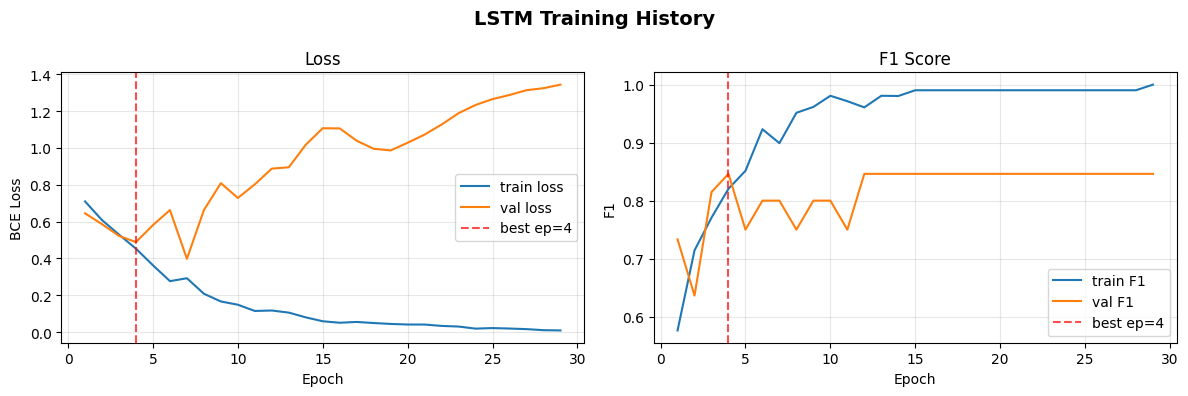

Saved training_curves.png


In [9]:
# ── 1.8  Plot training curves ─────────────────────────────────────────────────
epochs_ran = list(range(1, len(history['train_loss']) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_ran, history['train_loss'], label='train loss')
ax1.plot(epochs_ran, history['val_loss'],   label='val loss')
ax1.axvline(best_epoch, color='red', linestyle='--', alpha=0.7, label=f'best ep={best_epoch}')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, history['train_f1'], label='train F1')
ax2.plot(epochs_ran, history['val_f1'],   label='val F1')
ax2.axvline(best_epoch, color='red', linestyle='--', alpha=0.7, label=f'best ep={best_epoch}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1')
ax2.set_title('F1 Score'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('LSTM Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')

## 1.9  Quick Validation on Test Set

In [10]:
# ── 1.9  Quick test-set check ─────────────────────────────────────────────────
# Restore best weights
model.load_state_dict(best_state)
model.eval()

all_preds, all_true, all_probs = [], [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        logits = model(Xb.to(DEVICE))
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs >= THRESHOLD).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_true.extend(yb.long().numpy())

print('=== Test Set Results (best weights) ===')
print(classification_report(all_true, all_preds, target_names=['wrong', 'correct']))
test_f1 = f1_score(all_true, all_preds, zero_division=0)
print(f'Test F1 (macro): {f1_score(all_true, all_preds, average="macro", zero_division=0):.4f}')

=== Test Set Results (best weights) ===
              precision    recall  f1-score   support

       wrong       0.77      0.83      0.80        12
     correct       0.82      0.75      0.78        12

    accuracy                           0.79        24
   macro avg       0.79      0.79      0.79        24
weighted avg       0.79      0.79      0.79        24

Test F1 (macro): 0.7913


## 1.10  Save Best Model

In [11]:
# ── 1.10  Save ────────────────────────────────────────────────────────────────
CKPT_PATH   = OUT_DIR / 'best_model.pt'
CONFIG_PATH = OUT_DIR / 'model_config.json'

torch.save({
    'epoch'       : best_epoch,
    'model_state' : best_state,
    'val_f1'      : best_val_f1,
    'threshold'   : THRESHOLD,
    'history'     : history,
}, CKPT_PATH)

model_cfg = {
    'architecture' : 'BiLSTM',
    'n_features'   : F,
    'T_fixed'      : T,
    'hidden'       : 64,
    'n_layers'     : 2,
    'dropout'      : 0.3,
    'bidirectional': True,
    'threshold'    : THRESHOLD,
    'best_epoch'   : best_epoch,
    'best_val_f1'  : round(best_val_f1, 4),
    'feature_cols' : ds_cfg['feature_cols'],
    'feat_mean'    : ds_cfg['feat_mean'],
    'feat_std'     : ds_cfg['feat_std'],
    'label_map'    : ds_cfg['label_map'],
    'split'        : split_info,
    'dataset_stats': {
        'N': N, 'T': T, 'F': F,
        'n_correct': ds_cfg['n_correct'],
        'n_wrong'  : ds_cfg['n_wrong'],
    },
}
CONFIG_PATH.write_text(json.dumps(model_cfg, indent=2))

print(f'Model   → {CKPT_PATH}')
print(f'Config  → {CONFIG_PATH}')
print(f'Best epoch : {best_epoch}   Val F1 : {best_val_f1:.4f}')

Model   → models/best_model.pt
Config  → models/model_config.json
Best epoch : 4   Val F1 : 0.8462
